In [1]:
import ast
import os
import pandas as pd
import warnings

warnings.filterwarnings("ignore")

def extract_genus_name(x):
    try:
        genus_dict = ast.literal_eval(x)
        return genus_dict.get('name', None)
    except:
        return None

os.chdir('/active-data/analysis_results/chr_pla')
all_data = pd.read_csv('genome_chr-pla_statistics.csv')
all_data['genus_clean'] = all_data['genus'].apply(extract_genus_name)
counts = all_data['genus_clean'].value_counts()
keep_genus = counts[counts >= 400].index.to_list()
filted_data = all_data[all_data['genus_clean'].isin(keep_genus)]
print(keep_genus)

base_folder = f'/active-data/analysis_results/chr_pla/genus'
figure_data = f'{base_folder}/figure_data'
os.makedirs(figure_data, exist_ok=True)

['Escherichia', 'Klebsiella', 'Staphylococcus', 'Pseudomonas', 'Bacillus', 'Salmonella', 'Streptococcus', 'Streptomyces', 'Acinetobacter', 'Enterococcus', 'Bordetella', 'Enterobacter', 'Xanthomonas', 'Campylobacter', 'Vibrio', 'Mycobacterium', 'Corynebacterium', 'Burkholderia', 'Listeria', 'Citrobacter', 'Helicobacter']


In [2]:
# all_replicon
all_data = []
for genus_name in keep_genus:
    folder = f'{base_folder}/statistics_records/{genus_name}'
    os.chdir(folder)
    replicon_data = pd.read_csv('replicon-plasmid_fraction-self_bitscore_statistics.csv')
    replicon_data['genus'] = genus_name
    all_data.append(replicon_data)

all_contig = pd.concat(all_data, ignore_index=True)
all_contig['acc_n'] = all_contig['accession'].str.split('-').str[0]
all_contig['GC_bases'] = all_contig['size'] * all_contig['GC_content']

genome_gc_result = all_contig.groupby('acc_n').agg(size_bp=('size', 'sum'), GC_bp=('GC_bases', 'sum')).reset_index()
genome_gc_result['GC_content'] = genome_gc_result['GC_bp'] / genome_gc_result['size_bp']

In [3]:
IR_replicon = all_contig[all_contig['category-pident_90'] == 'intermediate replicon'].copy().reset_index(drop=True)
IR_replicon = IR_replicon[['organism', 'accession', 'size', 'average plasmid fraction-pident_90', 'GC_content', 'genus']]
IR_replicon['acc_n'] = IR_replicon['accession'].str.split('-').str[0]
IR_replicon['contig'] = IR_replicon['accession'].str.split('-').str[1]
IR_replicon['contig_'] = IR_replicon['accession'].apply(lambda x: x.split('-')[-1].split('.')[0])

In [4]:
import textract

# chromid reference data

file_path = "/active-data/analysis_results/chr_pla/reference_data/PMID20080407/1-s2.0-S0966842X09002698-mmc1.doc"
content = textract.process(file_path, encoding="utf-8")
content = content.decode("utf-8")

ref1_list = []
for line in content.splitlines():
    if "Chromid" in line and '|' in line:
        parts = line.split("|")
        nc_code = parts[4].strip()
        ref1_list.append(nc_code.replace(' ', '_'))

file_path = "/active-data/analysis_results/chr_pla/reference_data/PMID40827884/msystems.00175-25-s0003.xlsx"

df = pd.read_excel(file_path, skiprows=1)
chromid_ref = df[df['GC_difference_%'] != 0]
ref2_list = chromid_ref['Replicon_Accession'].to_list()

# chromid-finder data
found_chromids = []
chromid_dir = '/active-data/genomes/bacteria_complete_annotationRefSeq-20250807/chromid_results'
for acc_n in filted_data['accession']:
    file_path = f'{chromid_dir}/{acc_n}.txt'
    
    if os.path.getsize(file_path) == 0:
        continue
    
    with open(file_path, 'r', encoding='utf-8') as f:
        lines = f.readlines()
        
        for i, line in enumerate(lines):
            if "Possible bacterial chromids:" in line:
                if i + 1 >= len(lines):
                    continue
                chromid_line = lines[i+1].strip()
                if not chromid_line or chromid_line == '------':
                    break
                
                chromid_list = [c.strip() for c in chromid_line.split(",") if c.strip()]
                for chromid in chromid_list:
                    found_chromids.append(chromid.split('.')[0])


def chromid_info_(contig_info, all_chromids=set(ref1_list + ref2_list + found_chromids)):
    contig_info = contig_info.copy()
    contig_info['contig'] = contig_info['accession'].apply(lambda x: x.split('-')[-1].split('.')[0])
    chromid_result = contig_info[contig_info['contig'].isin(all_chromids)].copy()
    return chromid_result

chromid_result = chromid_info_(all_contig).reset_index(drop=True)
chromid_result = chromid_result[['organism', 'accession', 'size', 'average plasmid fraction-pident_90', 'GC_content', 'genus']]
chromid_result['acc_n'] = chromid_result['accession'].str.split('-').str[0]
chromid_result['contig'] = chromid_result['accession'].str.split('-').str[1]
chromid_result['contig_'] = chromid_result['accession'].apply(lambda x: x.split('-')[-1].split('.')[0])

In [5]:
# ori data
all_ori_data = []
for genus_name in keep_genus:
    path = f'{base_folder}/statistics_records/{genus_name}/Ori_finder/ori_results.csv'
    df = pd.read_csv(path)
    all_ori_data.append(df)

all_ori_data = pd.concat(all_ori_data, ignore_index=True)[['accession', 'oriC(ORCA)', 'oriV(OriV-Finder)']]
IR_ori = all_ori_data[all_ori_data['accession'].isin(IR_replicon['accession'])]
chromid_ori = all_ori_data[all_ori_data['accession'].isin(chromid_result['accession'])]

In [6]:
#gene_content
from tqdm import tqdm

def typical_gene_content(fraction_data, label):    
    gene_content = {'all':0}
    head = 'query	seed_ortholog	evalue	score	eggNOG_OGs	max_annot_lvl	COG_category	Description	Preferred_name	GOs	EC	KEGG_ko	KEGG_Pathway	KEGG_Module	KEGG_Reaction	KEGG_rclass	BRITE	KEGG_TC	CAZy	BiGG_Reaction	PFAMs'.split('\t')
    char_gene_pre = ['rep', 'tra', 'par', 'sop', 'dna' ]
    pattern = r'^(' + '|'.join(char_gene_pre) + ')'
    with tqdm(total = len(fraction_data), desc=f'{label}', leave=True, ncols=100, unit='B', unit_scale=True) as pbar:
        for index, row in fraction_data.iterrows():
            contig = row['accession']
            acc = contig.split('-')[0]
            eggnog_file = pd.read_csv(f'/active-data/genomes/bacteria_complete_annotationRefSeq-20250807/eggnog_results/{acc}/{acc}.emapper.annotations', comment = '#', sep = '\t', header = None, names = head)
            eggnog_file = eggnog_file[eggnog_file['query'].str.contains(contig)]
            plasmid_genes = eggnog_file[eggnog_file['Preferred_name'].str.contains(pattern, case=False, na=False, regex=True)]
            gene_set = set(plasmid_genes['Preferred_name'])
            gene_content['all'] += 1
            for gene in gene_set:
                try:
                    gene_content[gene[:4]] += 1
                except:
                    gene_content[gene[:4]] = 1
            pbar.update(1)

    return gene_content

IR_gene_content = typical_gene_content(IR_replicon, label='intermediate replicon')
chromid_gene_content = typical_gene_content(chromid_result, label='chromid')

chromid: 100%|██████████████████████████████████████████████████████| 742/742 [00:26<00:00, 28.1B/s]


In [7]:
#COG_data
all_cog_data = []
for genus_name in keep_genus:
    os.chdir(f'{base_folder}/statistics_records/{genus_name}')
    rep_COG_data = pd.read_csv('COG_statistics.tsv', sep='\t')
    numeric_cols = rep_COG_data.select_dtypes(include=['int64', 'float64']).columns.tolist()
    all_cog_data.append(rep_COG_data)

denominator_col = "All coding CDSs"
# denominator_col = "Categorized CDSs"
all_cog_data = pd.concat(all_cog_data, ignore_index=True)
exclude_cols = ["accession", "All coding CDSs", "Categorized CDSs"]
letter_cols = [col for col in all_cog_data.columns if len(col)==1]

IR_cog = all_cog_data[all_cog_data['accession'].isin(IR_replicon['accession'])]
sum_IR_cog = IR_cog[numeric_cols].sum().reset_index()
sum_IR_cog = sum_IR_cog.set_index("index")[0]
IR_cog_data = {'category': 'Intermediate replicon'}
for col in letter_cols:
    IR_cog_data[col] = sum_IR_cog[col] / sum_IR_cog[denominator_col] * 100

chromid_cog = all_cog_data[all_cog_data['accession'].isin(chromid_result['accession'])]
sum_chromid_cog = chromid_cog[numeric_cols].sum().reset_index()
sum_chromid_cog = sum_chromid_cog.set_index("index")[0]
chromid_cog_data = {'category': 'Chromid'}
for col in letter_cols:
    chromid_cog_data[col] = sum_chromid_cog[col] / sum_chromid_cog[denominator_col] * 100

chromid_cog_data = pd.DataFrame([chromid_cog_data])
IR_cog_data = pd.DataFrame([IR_cog_data])
cog_data = pd.concat([IR_cog_data, chromid_cog_data], ignore_index=True)


In [8]:
# GC_content

IR_GC = pd.merge(IR_replicon[['accession', 'acc_n', 'GC_content']], genome_gc_result[['acc_n', 'GC_content']], on='acc_n', how='left')
chromid_GC = pd.merge(chromid_result[['accession', 'acc_n', 'GC_content']], genome_gc_result[['acc_n', 'GC_content']], on='acc_n', how='left')

In [9]:
# k-mer
from collections import defaultdict

def load_single_kmer(kmer_dir, record_id, target_k):
    kmer_file = os.path.join(kmer_dir, f"{record_id}.txt")
    if not os.path.exists(kmer_file):
        return None
    with open(kmer_file, 'r') as f:
        raw = f.read()
        kmer_dict = ast.literal_eval(raw)
        
    k_key = f"{target_k}-mer"
    if k_key not in kmer_dict:
        return None
    kmer_counts = kmer_dict[k_key]
    valid_bases = {"A", "T", "C", "G"}
    clean_counts = {}
    for seq, cnt in kmer_counts.items():
        if set(seq).issubset(valid_bases):
            clean_counts[seq] = cnt
    total = sum(clean_counts.values())
    if total == 0:
        return None
    return {f"{seq}": cnt / total for seq, cnt in clean_counts.items()}

def k_mer_data(df, label):
    kmer_base_dir = "/active-data/genomes/bacteria_complete_annotationRefSeq-20250807/kmer"
    k_values = [3, 4, 5]
    group_dict = defaultdict(list)
    for k in k_values:
        with tqdm(total = len(df), desc=f'{label}_{k}-mer', leave=True, ncols=100, unit='B', unit_scale=True) as pbar:
            for idx, row in df.iterrows():
                acc_n = row["accession"].split('-')[0]
                record_id = row["accession"].split('-')[1]
                full_acc = row["accession"]
                kmer_dir = os.path.join(kmer_base_dir, acc_n)
                kmer_freq = load_single_kmer(kmer_dir, record_id, k)
                group_dict[k].append((kmer_freq, full_acc))
                pbar.update(1)
    return group_dict

IR_k_mer = k_mer_data(IR_replicon, 'intermediate replicon')
chromid_k_mer = k_mer_data(chromid_result, 'chromid')

chromid_5-mer: 100%|█████████████████████████████████████████████████| 742/742 [00:03<00:00, 199B/s]


In [10]:
from sklearn.decomposition import PCA
from skbio.stats.distance import anosim
from skbio.stats.distance import DistanceMatrix
from scipy.spatial.distance import pdist, squareform
import numpy as np
np.random.seed(42)

def build_feature_table(g1, g2):
    data_list = []
    label_list = []
    for kmer_dict, cid in g1:
        data_list.append(kmer_dict)
        label_list.append("Intermediate replicon")
    for kmer_dict, cid in g2:
        data_list.append(kmer_dict)
        label_list.append("Chromid")
    df = pd.DataFrame(data_list).fillna(0.0)
    return df, np.array(label_list)

PCA_ANOSIM_R_results = {}

for k in [3, 4, 5]:
    group1 = IR_k_mer[k]
    group2 = chromid_k_mer[k]

    df, group_labels = build_feature_table(group1, group2)
    X_raw = df.values

    # PCA
    pca = PCA(n_components=2)
    pca_coords = pca.fit_transform(X_raw)
    r2_pc1 = pca.explained_variance_ratio_[0]
    r2_pc2 = pca.explained_variance_ratio_[1]

    # ANOSIM Bray-Curtis
    dist_vec = pdist(X_raw, metric='braycurtis')
    dist_mat = squareform(dist_vec)
    dm = DistanceMatrix(dist_mat)
    anosim_result = anosim(dm, group_labels, permutations=999)
    anosim_R = anosim_result['test statistic']
    anosim_p = anosim_result['p-value']

    PCA_ANOSIM_R_results[k] = {
        "PC1_R2": r2_pc1,
        "PC2_R2": r2_pc2,
        "Cumulative_R2": r2_pc1 + r2_pc2,
        "ANOSIM_R": anosim_R,
        "ANOSIM_P": anosim_p,
        "PCA_coordinates": pca_coords,
        "group_labels": group_labels
    }

In [11]:
# psudogene

all_psudo_data = []
for genus_name in keep_genus:
    folder = f'{base_folder}/statistics_records/{genus_name}'
    os.chdir(folder)
    pseudogene_data = pd.read_csv('pseudogene_statistics.tsv', sep='\t')
    pseudogene_data = pseudogene_data[pseudogene_data['CDSs (total)'] > 0]
    all_psudo_data.append(pseudogene_data)

all_psudo_data = pd.concat(all_psudo_data, ignore_index=True)
all_psudo_data['Pseudogene percentage (%)'] = all_psudo_data['CDSs (without protein, Pseudo Genes)'] / all_psudo_data['CDSs (total)'] * 100

IR_psudo = all_psudo_data[all_psudo_data['contig'].isin(IR_replicon['accession'])]
chromid_psudo = all_psudo_data[all_psudo_data['contig'].isin(chromid_result['accession'])]

In [12]:
article_id = ['PMID40603865', 'PMID40603299']
PCN1 = pd.read_csv(f'/active-data/analysis_results/chr_pla/reference_data/{article_id[0]}/Fig1BC-Source-Data.csv')
PCN1 = PCN1.rename(columns={'SeqID': 'Contig', 'PIRACopyNumber': 'Copy number'})
PCN1['Copy number (log10)'] = np.log10(PCN1['Copy number'])

IR_PCN = PCN1[PCN1['Contig'].isin(IR_replicon['contig'])][['Contig', 'Copy number', 'Copy number (log10)']]
chromid_PCN = PCN1[PCN1['Contig'].isin(chromid_result['contig'])][['Contig', 'Copy number', 'Copy number (log10)']]

In [13]:
def plot_oriC_or_oriV(ax, data, colors, labels):
    x = np.arange(2)
    ax.bar(x, data, color=colors, width=0.6, alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=30, ha='right', va='top', rotation_mode='anchor')
    ax.set_ylim(0,105)
    ax.set_xlim(-0.5,len(x)-0.5)

def plot_gene_content(ax, genes, ir, ch, colors):
    char_gene_pre = ['tra', 'par', 'sop', 'rep', 'dna']
    gene_priority = {pre: idx for idx, pre in enumerate(char_gene_pre)}

    def sort_key(gene):
        for pre in char_gene_pre:
            if gene.startswith(pre):
                return (gene_priority[pre], gene)
        return (len(char_gene_pre), gene)

    sorted_pairs = sorted(zip(genes, ir, ch), key=lambda x: sort_key(x[0]))
    genes, ir, ch = map(list, zip(*sorted_pairs)) if sorted_pairs else ([], [], [])
    
    x = np.arange(len(genes))
    w = 0.8 / 2
    
    ax.bar(x - w/2, ir, w, label='Intermediate replicon (IR)', color=colors[0], alpha=0.8)
    ax.bar(x + w/2, ch, w, label='Chromid', color=colors[1], alpha=0.8)
    
    ax.set_xticks(x)
    ax.set_xticklabels(genes, rotation=45, ha='right', va='top', rotation_mode='anchor', style='italic')
    ax.legend(loc='upper left')
    ax.set_ylim(0, 105)
    ax.set_xlim(-0.5, len(genes) - 0.5)

    color_map = {'rep': '#1B9E77', 'tra': '#A6761D', 'par': '#7570B3', 'sop': '#7570B3', 'dna': '#1B9E77',}
    gene_prefixes = ['rep', 'tra', 'par', 'sop', 'dna']
    for tick_label in ax.get_xticklabels():
        gene = tick_label.get_text()
        for pre in gene_prefixes:
            if gene.startswith(pre):
                tick_label.set_color(color_map[pre])
                break

    gene_indices = defaultdict(list)
    for idx, gene in enumerate(genes):
        for prefix in gene_prefixes:
            if gene.startswith(prefix):
                gene_indices[prefix].append(idx)
                break

    groups = [
        ('tra', '#A6761D', 'Plasmid transfer genes'),
        ('par_sop', '#7570B3', 'Partition genes'),
        ('rep_dna', '#1B9E77', 'Replication genes')
    ]

    y_top = ax.get_ylim()[1]
    rect_height = 5
    for prefix_group, color, label in groups:
        if prefix_group == 'tra':
            indices = gene_indices.get('tra', [])
        elif prefix_group == 'par_sop':
            indices = gene_indices.get('par', []) + gene_indices.get('sop', [])
        else:
            indices = gene_indices.get('rep', []) + gene_indices.get('dna', [])
        
        if not indices:
            continue
        left, right = min(indices) - 0.5, max(indices) + 0.5
        ax.add_patch(plt.Rectangle((left, y_top + 1), right-left, rect_height, 
                                   color=color, alpha=0.7, lw=0, clip_on=False))
        ax.text((left+right)/2, y_top + 1 + rect_height, label, 
                ha='center', va='bottom', fontsize=7, color=color)

    major_groups = [{'tra'}, {'par', 'sop'}, {'rep', 'dna'}]
    if len(genes) == 0:
        return
    
    prev_prefix = None
    prev_major_group = None
    for idx, gene in enumerate(genes):
        curr_prefix = None
        for p in gene_prefixes:
            if gene.startswith(p):
                curr_prefix = p
                break
        if not curr_prefix:
            continue

        curr_major_group = None
        for g in major_groups:
            if curr_prefix in g:
                curr_major_group = g
                break

        if idx == 0:
            prev_prefix = curr_prefix
            prev_major_group = curr_major_group
            continue

        x_line = idx - 0.5
        if curr_major_group != prev_major_group:
            ax.axvline(x=x_line, color='#707070', lw=1.0, linestyle='-', zorder=0)
        elif curr_prefix != prev_prefix:
            ax.axvline(x=x_line, color='#AAAAAA', lw=0.8, linestyle='--', zorder=0)
        else:
            ax.axvline(x=x_line, color='#DDDDDD', lw=0.5, linestyle=':', zorder=0)

        prev_prefix = curr_prefix
        prev_major_group = curr_major_group

In [14]:
def cog_cat_draw(ax, data, letter_pct_cols, colors, labels):
    x = np.arange(len(letter_pct_cols))
    width = 0.75 / 2

    for idx, lab in enumerate(labels):
        row_data = data[data['category']==lab][letter_pct_cols].values
        ax.bar(x + width*(-0.5 + idx), row_data[0], width, label=lab, color=colors[idx], alpha=0.8)
    
    ax.set_xlabel("COG category")
    ax.set_ylabel("Protein percentage (%)")
    ax.set_xticks(x)
    ax.set_xticklabels(letter_pct_cols)
    ax.set_xlim(-0.5, len(letter_pct_cols)-0.5)
    ax.legend(loc='best')

def cog_scatter_xy(ax, cog_data, cog_color_dict):
    ir_row = cog_data[cog_data["category"] == "Intermediate replicon"].iloc[0]
    ch_row = cog_data[cog_data["category"] == "Chromid"].iloc[0]
    cog_cols = cog_data.columns[1:]

    x = [ir_row[c] for c in cog_cols]
    y = [ch_row[c] for c in cog_cols]
    labels = cog_cols
    point_colors = [cog_color_dict[lab] for lab in labels]

    ax.scatter(x, y, s=8, alpha=0.7, c=point_colors)

    x_min, x_max = ax.get_xlim()
    y_min, y_max = ax.get_ylim()
    for xi, yi, lab in zip(x, y, labels):
        ax.text(xi + x_max*0.005, yi + y_max*0.005, lab)
        
    lim_max = max(max(x), max(y))*1.1
    ax.plot([0, lim_max], [0, lim_max], 'k--', lw=1, alpha=0.5, label='y=x')

    ax.set_xlabel('Intermediate replicon\nprotein percentage (%)')
    ax.set_ylabel('Chromid\nprotein percentage (%)')
    ax.set_xlim(right=lim_max)
    ax.set_ylim(top=lim_max)

In [15]:
from scipy import stats

def GC_data_figure(ax, plot_data, replicon_type, color):
    ax.scatter(plot_data["GC_content_y"], plot_data["GC_content_x"], c=color, alpha=0.7, s=3, edgecolors="black", linewidth=0)
    
    x = plot_data["GC_content_y"]
    y = plot_data["GC_content_x"]
    
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    r2 = r_value ** 2
    n = len(x)
    
    t = stats.t.ppf(0.975, df=n-2)
    err_slope = t * std_err
    err_intercept = err_slope * np.sqrt(np.mean(x**2))
    
    x_fit = np.linspace(0, 1, 100)
    y_fit = slope * x_fit + intercept
    ax.plot(x_fit, y_fit, '--', lw=1, c=color, label='Linear fit')
    
    fit_text = (
        f'$y = ax + b$\n'
        f'$R^2 = {r2:.3f}$'
    )
    
    ax.text(0.01, 0.99, fit_text, verticalalignment='top', horizontalalignment='left', fontsize=6)

    para_text = (
        f'$a = {slope:.3f} \\pm {err_slope:.3f}$\n'
        f'$b = {intercept:.3f} \\pm {err_intercept:.3f}$'
    )
    
    ax.text(0.99, 0.01, para_text, verticalalignment='bottom', horizontalalignment='right', fontsize=6)

    ax.set_xlabel("GC (Entire genome)",)
    ax.set_title(replicon_type, pad=3)
    
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.tick_params(axis="both", which="major")
    ax.set_ylabel("GC (Replicon)",)

In [16]:
def PCA_scatter_plot(ax, pca_result_dict, groups, colors, labels):
    coords = pca_result_dict["PCA_coordinates"]
    group_arr = pca_result_dict["group_labels"]
    pc1 = coords[:, 0]
    pc2 = coords[:, 1]

    for i, target_group in enumerate(groups):
        mask = group_arr == target_group
        ax.scatter(
            pc1[mask],
            pc2[mask],
            color=colors[i],
            label=f'{labels[i]}',
            alpha=0.6,
            s=2.5
        )

    r2_pc1 = pca_result_dict["PC1_R2"] * 100
    r2_pc2 = pca_result_dict["PC2_R2"] * 100
    ax.set_xlabel(f'PC1 ({r2_pc1:.2f}%)')
    ax.set_ylabel(f'PC2 ({r2_pc2:.2f}%)', labelpad=0)

def plot_anosim_r_bar(ax, result_dict, bar_color="#4472C4", sig_threshold=0.05):
    k_list = sorted(result_dict.keys())
    r_list = [result_dict[k]["ANOSIM_R"] for k in k_list]
    p_list = [result_dict[k]["ANOSIM_P"] for k in k_list]

    x = np.arange(len(k_list))
    w = 0.6
    bars = ax.bar(x, r_list, width=w, color=bar_color, alpha=0.8)

    for idx, (r, p) in enumerate(zip(r_list, p_list)):
        if p < sig_threshold:
            ax.text(x[idx], r + 0.005*max(r_list), "*", ha="center", fontsize=9)

    ax.set_xticks(x)
    ax.set_xticklabels([f"{k}-mer" for k in k_list])
    ax.set_xlabel(r"$\mathit{k}$-mer")
    ax.set_ylabel(r"ANOSIM $\mathit{R}$ value")
    ax.set_ylim(top=max(r_list)*1.15)

In [17]:
def violin_plot(ax, df_list, colors, labels, y_col, scatter=False):
    data_all = []
    for df in df_list:
        vals = df[y_col].dropna().values
        data_all.append(vals)
    
    positions = np.arange(len(data_all))
    vp = ax.violinplot(
        data_all,
        positions=positions,
        showmeans=False,
        showmedians=False,
        showextrema=False
    )
    for idx, body in enumerate(vp["bodies"]):
        body.set_facecolor(colors[idx])
        body.set_alpha(0.6)

    if scatter:
        jitter_scale = 0.22
        for i, arr in enumerate(data_all):
            x_jit = np.random.normal(loc=i, scale=jitter_scale/4, size=len(arr))
            ax.scatter(x_jit, arr, color=colors[i], s=6, alpha=0.35, zorder=2)

    ax.set_xticks(positions)
    ax.set_xticklabels(labels)
    ax.set_ylabel(y_col)
    ax.grid(axis="y", alpha=0.3, lw=0.3)

    if len(data_all) == 2:
        group1, group2 = data_all
        t_stat, p_val = stats.ttest_ind(group1, group2, equal_var=False)
        
        if p_val < 0.001:
            sig_mark = "***"
        elif p_val < 0.01:
            sig_mark = "**"
        elif p_val < 0.05:
            sig_mark = "*"
        else:
            sig_mark = "ns"
        
        y_max = max(np.max(group1), np.max(group2))
        y_line = y_max + (y_max * 0.06)
        ax.plot([0, 1], [y_line, y_line], c="black", lw=1)
        ax.text(0.5, y_line + (y_max * 0.005), sig_mark, ha="center", fontsize=9)
        ax.set_ylim(top=y_line + (y_max * 0.08))

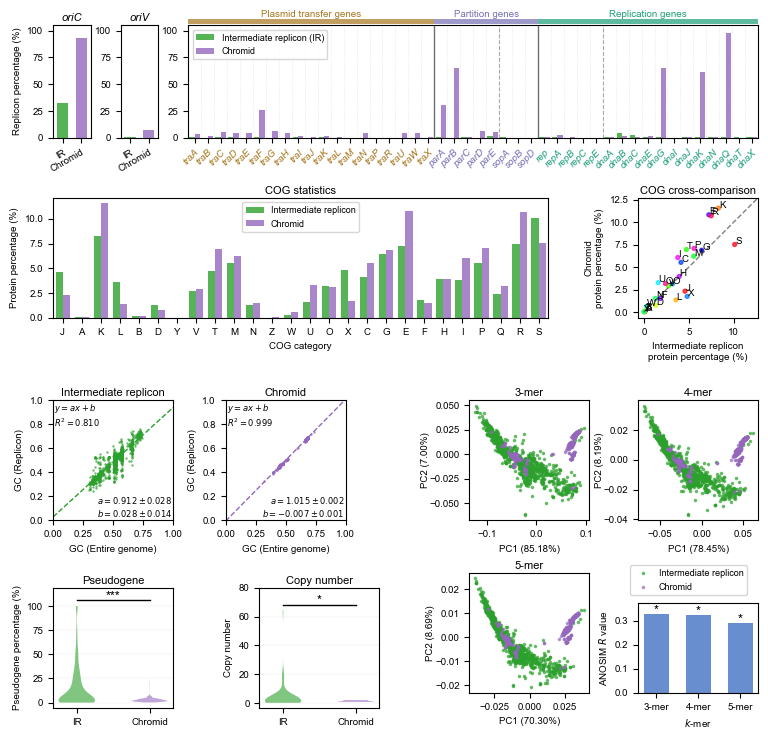

In [18]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

plt.rcParams["font.family"] = ["Arial"]
plt.rcParams.update({
    "font.size": 7,
    "axes.titlesize": 8,
    "axes.labelsize": 7,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 6.5,
})

color_dict = {'intermediate replicon': plt.cm.tab10(2), 'chromid': plt.cm.tab10(4)}
color_list = [plt.cm.tab10(2), plt.cm.tab10(4)]
label_list = ['IR', 'Chromid']

fig = plt.figure(figsize=(7.5, 7.5))

rep_y_site = 1 - 0.17
ax_oriC = fig.add_axes([0.06, rep_y_site, 0.05, 0.15])
oriC_data = [len(IR_ori[IR_ori['oriC(ORCA)'] == 'Y'])/len(IR_ori)*100, len(chromid_ori[chromid_ori['oriC(ORCA)'] == 'Y'])/len(chromid_ori)*100]
plot_oriC_or_oriV(ax_oriC, oriC_data, color_list, label_list)
ax_oriC.set_title('oriC', pad=3).set_fontstyle('italic')
ax_oriC.set_ylabel('Replicon percentage (%)')

ax_oriV = fig.add_axes([0.15, rep_y_site, 0.05, 0.15])
oriV_data = [len(IR_ori[IR_ori['oriV(OriV-Finder)'] == 'Y'])/len(IR_ori)*100, len(chromid_ori[chromid_ori['oriV(OriV-Finder)'] == 'Y'])/len(chromid_ori)*100]
plot_oriC_or_oriV(ax_oriV, oriV_data, color_list, label_list)
ax_oriV.set_title('oriV', pad=3).set_fontstyle('italic')

ax_gene_content = fig.add_axes([0.24, rep_y_site, 1-0.24, 0.15])
def process_gene_content(IR_gene_content, chromid_gene_content):
    def pct(d): 
        total=d['all']
        return {k:v/total*100 for k,v in d.items() if k!='all'}
    def a(d): 
        return [d.get(g,0) for g in genes]
    IR_gene = pct(IR_gene_content)
    ch_gene = pct(chromid_gene_content)
    genes = sorted(set(IR_gene)|set(ch_gene), key=lambda g:next((i for i,p in enumerate(['tra','par','sop','rep','dna'])if g.startswith(p)),99))
    return genes, a(IR_gene), a(ch_gene)
genes, IR_gene, ch_gene = process_gene_content(IR_gene_content, chromid_gene_content)
plot_gene_content(ax_gene_content, genes, IR_gene, ch_gene, color_list)

cog_cat_x_site = 0
cog_cat_y_site = rep_y_site - 0.24
ax_cog_category = fig.add_axes([cog_cat_x_site+0.06, cog_cat_y_site, 0.66, 0.16])
cog_cat_draw(ax_cog_category, cog_data, letter_cols, color_list, ['Intermediate replicon', 'Chromid'])
ax_cog_category.set_title('COG statistics', pad=3)

n_cog = len(letter_cols)
cog_color_list = []
for i in range(n_cog):
    norm_val = i / (n_cog - 1)
    cog_color_list.append(plt.cm.hsv(norm_val))
cog_color_dict = dict(zip(letter_cols, cog_color_list))
cog_x_site = 0.84
cog_y_site = cog_cat_y_site
ax_cog_scatter = fig.add_axes([cog_x_site, cog_y_site, 0.16, 0.16])
cog_scatter_xy(ax_cog_scatter, cog_data, cog_color_dict)
ax_cog_scatter.set_title('COG cross-comparison', pad=3)

GC_size = 0.16
GC_x_site = 0
GC_y_site = cog_y_site - (GC_size + 0.08 + 0.03)
ax_IR_GC = fig.add_axes([GC_x_site + 0.06, GC_y_site, GC_size, GC_size])
ax_ch_GC = fig.add_axes([GC_x_site + 0.06 + GC_size + 0.07, GC_y_site, GC_size, GC_size])
GC_data_figure(ax_IR_GC, IR_GC, 'Intermediate replicon', color_list[0])
GC_data_figure(ax_ch_GC, chromid_GC, 'Chromid', color_list[1])

k_mer = ['3', '4', '5']
PCA_x_site = 0.555
PCA_y_site = GC_y_site # - (0.2 + 0.03)
ax_PCA = {}
for i in range(len(k_mer)):
    ax_PCA[k_mer[i]] = fig.add_axes([PCA_x_site + 0.06 + (0.225)*(i%2), PCA_y_site - int(i/2)*(0.2 + 0.03), 0.16, 0.16])
    PCA_scatter_plot(ax_PCA[k_mer[i]], PCA_ANOSIM_R_results[int(k_mer[i])], ['Intermediate replicon', 'Chromid'], color_list, ['Intermediate replicon', 'Chromid'])
    ax_PCA[k_mer[i]].set_title(f'{k_mer[i]}-mer', pad=3)
ax_PCA['5'].legend(bbox_to_anchor=(1.3, 1.1), loc='upper left')

i+=1
ax_ANOSIM_R = fig.add_axes([PCA_x_site + 0.06 + (0.225)*(i%2), PCA_y_site - int(i/2)*(0.2 + 0.03), 0.16, 0.12])
plot_anosim_r_bar(ax_ANOSIM_R, PCA_ANOSIM_R_results, bar_color="#4472C4", sig_threshold=0.05)

Pseudo_x_site = 0.06
Pseudo_y_site = PCA_y_site - (0.2 + 0.05)
ax_pseudogene = fig.add_axes([Pseudo_x_site, Pseudo_y_site, 0.16, 0.16])
violin_plot(ax_pseudogene, [IR_psudo, chromid_psudo], color_list, label_list, y_col="Pseudogene percentage (%)")
ax_pseudogene.set_ylim(top=119)
ax_pseudogene.set_title('Pseudogene', pad=3)

PCN_x_site = Pseudo_x_site + 0.275
PCN_y_site = Pseudo_y_site
ax_copynumber = fig.add_axes([PCN_x_site, PCN_y_site, 0.16, 0.16])
violin_plot(ax_copynumber, [IR_PCN, chromid_PCN], color_list, label_list, y_col="Copy number")
#ax_copynumber.set_yscale("log")
ax_copynumber.set_ylim(top=80)
ax_copynumber.set_title('Copy number', pad=3)

rect = plt.Rectangle((0, 0), 1, 1, transform=fig.transFigure, facecolor='none', edgecolor='black', linewidth=2)
#fig.patches.append(rect)

base_folder = f'/active-data/analysis_results/chr_pla/genus'
figure_fold = f'{base_folder}/figures'
os.chdir(figure_fold)
plt.savefig(f"S_IR_vs_Chromid.svg", bbox_inches="tight", transparent=True)
plt.savefig(f"S_IR_vs_Chromid.png", dpi=1000, bbox_inches="tight", transparent=True)
fig.show()